In [1]:
!pip install yfinance
!pip install PANDAS
!pip install numpy
!pip install pandas
!pip install statsmodels
!pip install arch

import numpy as np
import yfinance as yf
from scipy.stats import norm, t
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
from arch.univariate import volatility
from scipy.stats import chi2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.2 MB/s eta 0:00:00


In [69]:
data = yf.download(["SPY", "GLD", "NDIA.L", "VWRP.L"], period="5y")
close_data = data['Close'].dropna()

spy_prices = np.array(close_data['SPY'])
gld_prices = np.array(close_data['GLD'])
ndia_prices = np.array(close_data['NDIA.L'])
vwrp_prices = np.array(close_data['VWRP.L'])

portfolio = []
portfolio.append(spy_prices)
portfolio.append(gld_prices)
portfolio.append(ndia_prices)
portfolio.append(vwrp_prices)

price_matrix = np.vstack(portfolio)
weight = np.array([0.25, 0.25, 0.25, 0.25])
print(price_matrix.shape)

def portfolio_vec(weight, price_matrix):
    percent=(price_matrix[:, 1:] - price_matrix[:, :-1]) / price_matrix[:, :-1]
    port_vec = np.dot(weight,price_matrix)
    percent_vec = np.dot(weight,percent)
    return percent,port_vec, percent_vec

percent,port_vec, percent_vec=portfolio_vec(weight, price_matrix)
percent_vec[percent_vec==0.0] =1e-8
percent_vec=percent_vec*100
print(percent_vec[:10])

/tmp/ipykernel_1430/3923058278.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["SPY", "GLD", "NDIA.L", "VWRP.L"], period="5y")
[*********************100%***********************]  4 of 4 completed

(4, 1227)
[ 0.09123446  0.27605322 -0.70410541 -0.53056629 -0.05424627  0.60384243
  0.24579002  0.67938172  0.01784756  0.00625486]


In [86]:

def portfolio_vec(weight, price_matrix):
  percent=(price_matrix[:, 1:] - price_matrix[:, :-1]) / price_matrix[:, :-1]
  percent[percent == 0.0] = 1e-8
  port_vec = np.dot(weight,price_matrix)
  percent_vec = np.dot(weight,percent)
  return percent,port_vec, percent_vec

def hist_risk(percent_vec,alpha):
  if len(percent_vec) <100:
    print(f"lack of data may lead to insufficient statistical reliability")
  w = np.sort(percent_vec)
  q = int(np.floor(alpha*len(percent_vec)))
  VaR = abs(w[q])

#move onto expected shortfall completing our historical risk fucntion
  E_SF = abs(np.mean(w[:q]))
  #print(f"The historical {alpha*100}% VaR for {len(percent_vec)} days is: {VaR}")
  #print(f"The historical {alpha*100}% Expected shortfall for {len(percent_vec)} days is: {E_SF}")
  return VaR, E_SF

def normal_riskp(alpha, percent_vec):
  #drift = np.mean(port_vec)
  sd = np.std(percent_vec)
  #sd =  np.sqrt(weight.T@np.cov(percent_vec, rowvar=True)@ weight)
  VaR = -sd*norm.ppf(alpha)

  #ES
  ES= sd*norm.pdf(norm.ppf(alpha))/alpha

  #print(f"The normal {alpha*100}% VaR for {percent_vec.shape[1]} days is: {VaR}")
  #print(f"The normal {alpha*100}% Expected shortfall for {percent_vec.shape[1]} days is: {ES}")
  return VaR, ES

def student_risk(alpha, percent_vec):
  mean=np.mean(percent_vec)
  avg_fourth = np.mean((percent_vec-mean)**4)
  std = np.std(percent_vec)**4
  E_kurtosis = avg_fourth/std
  kurtosis= E_kurtosis-3
  DF = (6/kurtosis)+4
  sd=np.std(percent_vec)
  #sd =  np.sqrt(weight.T@np.cov(percent_vec, rowvar=True)@ weight)
  VaR = -sd*t.ppf(alpha,DF)

  #ES
  ES = sd*(t.pdf(t.ppf(alpha,DF),DF)/alpha)*((DF+ t.ppf(alpha,DF)**2)/(DF-1))
  #print(f"The t dist {alpha*100}% VaR for {percent_vec.shape[1]} days is: {VaR}")
  #print(f"The t dist {alpha*100}% Expected shortfall for {percent_vec.shape[1]} days is: {ES}")
  return VaR, ES


def findGARCH(percent_vec):
  #the goal here is to create a function taht will use AIC to find an optimum GARCH based model
  GARCH_model_N_1 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=0, power= 2.0, dist = 'normal', rescale = False)
  GARCH_model_t_1 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=0, power= 2.0, dist = 'StudentsT', rescale = False)
  GARCH_model_N_2 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=0, power= 2.0, dist = 'normal', rescale = False)
  GARCH_model_t_2 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=0, power= 2.0, dist = 'StudentsT', rescale = False)
  GARCH_model_N_3 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=0, power= 2.0, dist = 'normal', rescale = False)
  GARCH_model_t_3 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=0, power= 2.0, dist = 'StudentsT', rescale = False)
  EGARCH_t = arch_model(percent_vec,mean = 'constant', lags=0, vol='EGARCH', p=1, q=1, o=1, dist = 'StudentsT', rescale = False)
  EGARCH_N = arch_model(percent_vec,mean = 'constant', lags=0, vol='EGARCH', p=1, q=1, o=1, dist = 'Normal', rescale = False)
  TGARCH_model_t_1 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 1.0, dist = 'StudentsT', rescale = False)
  TGARCH_model_N_2 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=1, power= 1.0, dist = 'normal', rescale = False)
  TGARCH_model_t_2 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=1, power= 1.0, dist = 'StudentsT', rescale = False)
  TGARCH_model_N_3 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=1, power= 1.0, dist = 'normal', rescale = False)
  TGARCH_model_t_3 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=1, power= 1.0, dist = 'StudentsT', rescale = False)
  GJR_GARCH_t_1 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 2.0, dist = 'StudentsT', rescale = False)
  GJR_GARCH_N_1 = arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 2.0, dist = 'Normal', rescale = False)

  GARCH_model_N_1=GARCH_model_N_1.fit(disp='off')
  GARCH_model_N_2=GARCH_model_N_2.fit(disp='off')
  GARCH_model_N_3=GARCH_model_N_3.fit(disp='off')
  GARCH_model_t_1=GARCH_model_t_1.fit(disp='off')
  GARCH_model_t_2=GARCH_model_t_2.fit(disp='off')
  GARCH_model_t_3=GARCH_model_t_3.fit(disp='off')
  EGARCH_t=EGARCH_t.fit(disp='off')
  EGARCH_N=EGARCH_N.fit(disp='off')
  TGARCH_model_t_1=TGARCH_model_t_1.fit(disp='off')
  TGARCH_model_N_2=TGARCH_model_N_2.fit(disp='off')
  TGARCH_model_t_2=TGARCH_model_t_2.fit(disp='off')
  TGARCH_model_N_3=TGARCH_model_N_3.fit(disp='off')
  TGARCH_model_t_3=TGARCH_model_t_3.fit(disp='off')
  GJR_GARCH_t_1=GJR_GARCH_t_1.fit(disp='off')
  GJR_GARCH_N_1=GJR_GARCH_N_1.fit(disp='off')





  models = {"GARCH_model_N_1":(GARCH_model_N_1.loglikelihood,GARCH_model_N_1.num_params),
            "GARCH_model_N_2":(GARCH_model_N_2.loglikelihood,GARCH_model_N_2.num_params),
            "GARCH_model_N_3":(GARCH_model_N_3.loglikelihood,GARCH_model_N_3.num_params),
            "GARCH_model_t_1":(GARCH_model_t_1.loglikelihood,GARCH_model_t_1.num_params),
            "GARCH_model_t_2":(GARCH_model_t_2.loglikelihood,GARCH_model_t_2.num_params),
            "GARCH_model_t_3":(GARCH_model_t_3.loglikelihood,GARCH_model_t_3.num_params),
            "EGARCH_t":(EGARCH_t.loglikelihood,EGARCH_t.num_params),
            "EGARCH_N":(EGARCH_N.loglikelihood,EGARCH_N.num_params),
            "TGARCH_model_t_1":(TGARCH_model_t_1.loglikelihood,TGARCH_model_t_1.num_params),
            "TGARCH_model_N_2":(TGARCH_model_N_2.loglikelihood,TGARCH_model_N_2.num_params),
            "TGARCH_model_t_2":(TGARCH_model_t_2.loglikelihood,TGARCH_model_t_2.num_params),
            "TGARCH_model_N_3":(TGARCH_model_N_3.loglikelihood,TGARCH_model_N_3.num_params),
            "TGARCH_model_t_3":(TGARCH_model_t_3.loglikelihood,TGARCH_model_t_3.num_params),
            "GJR_GARCH_t_1":(GJR_GARCH_t_1.loglikelihood,GJR_GARCH_t_1.num_params),
            "GJR_GARCH_N_1":(GJR_GARCH_N_1.loglikelihood,GJR_GARCH_N_1.num_params)}

  scoreS = {}
  fitted_objects = {
        "GARCH_model_N_1": GARCH_model_N_1, "GARCH_model_N_2": GARCH_model_N_2, "GARCH_model_N_3": GARCH_model_N_3,
        "GARCH_model_t_1": GARCH_model_t_1, "GARCH_model_t_2": GARCH_model_t_2, "GARCH_model_t_3": GARCH_model_t_3,
        "EGARCH_t": EGARCH_t, "EGARCH_N": EGARCH_N,
        "TGARCH_model_t_1": TGARCH_model_t_1, "TGARCH_model_N_2": TGARCH_model_N_2, "TGARCH_model_t_2": TGARCH_model_t_2,
        "TGARCH_model_N_3": TGARCH_model_N_3, "TGARCH_model_t_3": TGARCH_model_t_3,
        "GJR_GARCH_t_1": GJR_GARCH_t_1, "GJR_GARCH_N_1": GJR_GARCH_N_1}

  for name, (ll,n) in models.items():
    AIC = 2*n -2*ll

    BIC = n*np.log(len(percent_vec))- 2*ll
    scoreS[name] = {"AIC": AIC, "BIC": BIC}

    #getting the optimal model via smallest AIC value
  o_modelA = min(scoreS, key=lambda m: scoreS[m]["AIC"])
  o_modelB = min(scoreS, key=lambda m: scoreS[m]["BIC"])

  if o_modelA!=o_modelB:
      print("AIC and BIC do not agree so we will use model following BIC as its stricter")
      chosen_model = o_modelB
      return fitted_objects[chosen_model]
  else:
    print(f"agreeing AIC and BIC so {o_modelA}")
    chosen_model = o_modelA


    return fitted_objects[chosen_model]

def findGARCH(percent_vec):
  model_candidates = [
      ("GARCH_model_N_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=0, power= 2.0, dist = 'normal', rescale = False)),
      ("GARCH_model_t_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=0, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("GARCH_model_N_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=0, power= 2.0, dist = 'normal', rescale = False)),
      ("GARCH_model_t_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=0, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("GARCH_model_N_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=0, power= 2.0, dist = 'normal', rescale = False)),
      ("GARCH_model_t_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=0, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("EGARCH_t", arch_model(percent_vec,mean = 'constant', lags=0, vol='EGARCH', p=1, q=1, o=1, dist = 'StudentsT', rescale = False)),
      ("EGARCH_N", arch_model(percent_vec,mean = 'constant', lags=0, vol='EGARCH', p=1, q=1, o=1, dist = 'Normal', rescale = False)),
      ("TGARCH_model_t_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 1.0, dist = 'StudentsT', rescale = False)),
      ("TGARCH_model_N_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=1, power= 1.0, dist = 'normal', rescale = False)),
      ("TGARCH_model_t_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=1, power= 1.0, dist = 'StudentsT', rescale = False)),
      ("TGARCH_model_N_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=1, power= 1.0, dist = 'normal', rescale = False)),
      ("TGARCH_model_t_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=1, power= 1.0, dist = 'StudentsT', rescale = False)),
      ("GJR_GARCH_t_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("GJR_GARCH_N_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 2.0, dist = 'Normal', rescale = False))
  ]
#bug fix to assist with cleaning data
  successful_fitted_models = {}
  for name, model_instance in model_candidates:
    try:
      res=model_instance.fit(disp='off')
      if res.optimization_result.success:
        successful_fitted_models[name] = res
      else:
        print(f"Model {name} failed to converge (status {res.optimization_result.status}:{res.optimization_result.message}). Disqualifying.")
    except Exception as e:
      print(f"An error occurred while fitting model {name}:{e}. Disqualifying.")
  if not successful_fitted_models:
      print("No GARCH models converged successfully")
      return None

  scoreS = {}
  for name, res in successful_fitted_models.items():
      ll = res.loglikelihood
      n = res.num_params
      AIC = 2 * n - 2 * ll
      BIC = n * np.log(len(percent_vec)) - 2 * ll
      scoreS[name] = {"AIC": AIC, "BIC": BIC}

  o_modelA = min(scoreS, key=lambda m: scoreS[m]["AIC"])
  o_modelB = min(scoreS, key=lambda m: scoreS[m]["BIC"])

  if o_modelA != o_modelB:
      print(f"AIC and BIC do not agree. AIC chose {o_modelA}, BIC chose {o_modelB}. Using BIC's choice as it's stricter.")
      chosen_model = o_modelB
  else:
    print(f"AIC and BIC agree, choosing {o_modelA}")
    chosen_model = o_modelA

  return successful_fitted_models[chosen_model]


def compute_garch_risk(o_model, alpha, window):
    current_o_model = o_model
    try:
        from arch.univariate import EGARCH
        if isinstance(current_o_model.model.volatility, EGARCH):
            vol_str = 'EGARCH'
        else:
            vol_str = 'GARCH'
    except ImportError:
        vol_str = 'GARCH'

    dist_name_from_model = current_o_model.model.distribution.name
    if dist_name_from_model == "Normal":
        dist_arg = "normal"
    elif dist_name_from_model in ["StudentT", "Standardized Student's t"]:
        dist_arg = "studentst"
    else:
        dist_arg = dist_name_from_model.lower()

    power_val = getattr(current_o_model.model.volatility, 'power', 2.0)
    p_val = current_o_model.model.volatility.p
    q_val = current_o_model.model.volatility.q
    o_val = getattr(current_o_model.model.volatility, 'o', 0)

    Model = arch_model(window, mean='constant', lags=0, vol=vol_str, p=p_val, q=q_val, o=o_val, power=power_val, dist=dist_arg, rescale=False)
    res = Model.fit(disp='off')
  #DF = res.params['nu']
    forecasts = res.forecast()
    f_v=forecasts.variance.iloc[-1,0]
    f_SD =np.sqrt(f_v)
  #VaR_N= f_SD*norm.ppf(alpha)*value
  #VaR_t=f_SD*t.ppf(alpha,DF)*value
  #VaR_N_over_days = VaR_N*np.sqrt(T)
  #VaR_t_over_days = VaR_t*np.sqrt(T)

  #ES
  #ES_t = f_SD*(t.pdf(t.ppf(alpha,DF),DF)/alpha)*((DF+ t.ppf(alpha,DF)**2)/(DF-1))*value
  #ES_N= -*f_SD*norm.pdf(norm.ppf(alpha))/alpha *value
  #Now consider multio day VaR
  #ES_t_over_days = ES_t *np.sqrt(T)
  #ES_N_over_days =ES_N * np.sqrt(T)


    if 'nu' in res.params:
      DF = res.params['nu']
      VaR_t=-f_SD*t.ppf(alpha,DF)
      VaR_t_over_days = VaR_t
      ES_t = f_SD*(t.pdf(t.ppf(alpha,DF),DF)/alpha)*((DF+ t.ppf(alpha,DF)**2)/(DF-1))
      ES_t_over_days = ES_t
      return VaR_t_over_days, ES_t_over_days, res

    else:
      VaR_N= -f_SD*norm.ppf(alpha)
      VaR_N_over_days = VaR_N
      ES_N= f_SD*norm.pdf(norm.ppf(alpha))/alpha
      ES_N_over_days =ES_N
      return VaR_N_over_days,ES_N_over_days, res


  #return VaR_N_over_days,VaR_t_over_days,ES_t_over_days,ES_N_over_days


#https://tutorialreference.com/python/examples/faq/python-how-to-find-index-of-element-of-list-that-meet-a-condition
#def first_drop_point(data_list, threshold):
 #   sorted_list = sorted(data_list)
 #   for idx, value in enumerate(sorted_list):
  #      if value < threshold:
  #          return idx
  #  return None

def first_drop_point(data_list, threshold):
    sorted_list = sorted(data_list)
    for idx, value in enumerate(sorted_list):
        if value > threshold:
            return idx
    return len(sorted_list)
def ES_error(values, ES_val):
  sort_val = np.sort(values)

  n_H = first_drop_point(values, ES_val)
  below_vals = sort_val[:n_H]
  k_H = np.mean(below_vals)
  E_H = abs(k_H) - abs(ES_val)
  return E_H

def backtest(hist_percent_vec, BURNIN,alpha):
  ASSIST_FINDGARCH = hist_percent_vec[0:BURNIN]
  o_model=findGARCH(ASSIST_FINDGARCH)
  di = {"Date": [],
        "Simple_return": [],
        "N_breachoVaR": [],
        "T_breachoVaR": [],
        "H_breachoVaR": [],
        "G_breachoVaR": [],
        "N_ES": [],
        "T_ES": [],
        "H_ES": [],
        "G_ES": [],
        "N_VaR":[],
        "T_VaR":[],
        "H_VaR":[],
        "G_VaR":[],
        }

  BR_H=[]
  BR_N=[]
  BR_T=[]
  BR_G=[]
  ES_E_H=[]
  ES_E_N=[]
  ES_E_T=[]
  ES_E_G=[]
  for t in range(BURNIN,len(hist_percent_vec)):
    backtest_t = t - BURNIN
    t1=t-BURNIN
    t2 =t
    window =hist_percent_vec[t1:t2]
    di["Simple_return"].append(hist_percent_vec[t])
    di["Date"].append(t)


    H_VaR, H_E_SF=hist_risk(window,alpha)
    di["H_VaR"].append(H_VaR)
    di["H_ES"].append(H_E_SF)
    if hist_percent_vec[t] <-H_VaR:
      di["H_breachoVaR"].append(1)
    else:
      di["H_breachoVaR"].append(0)

    N_VaR, N_E_SF=normal_riskp(alpha,window)
    di["N_VaR"].append(N_VaR)
    di["N_ES"].append(N_E_SF)
    if hist_percent_vec[t] <-N_VaR:
      di["N_breachoVaR"].append(1)
    else:
      di["N_breachoVaR"].append(0)

    t_VaR, t_E_SF=student_risk(alpha, window)
    di["T_VaR"].append(t_VaR)
    di["T_ES"].append(t_E_SF)
    if hist_percent_vec[t] <-t_VaR:
      di["T_breachoVaR"].append(1)
    else:
      di["T_breachoVaR"].append(0)



    G_VaR, G_E_SF, o_model=compute_garch_risk(o_model, alpha,window)
    di["G_VaR"].append(G_VaR)
    di["G_ES"].append(G_E_SF)
    if hist_percent_vec[t] <-G_VaR:
      di["G_breachoVaR"].append(1)
    else:
      di["G_breachoVaR"].append(0)
    if backtest_t >= 100:
      values = hist_percent_vec[t-BURNIN:t]
      total_D =len(di["H_breachoVaR"])
      #Historical
      H_ES=di["H_ES"][-1]
      ES_E_H.append(ES_error(values, H_ES))
      BR_H.append(sum(di["H_breachoVaR"])/total_D)

      #Normal
      N_ES=di["N_ES"][-1]
      ES_E_N.append(ES_error(values, N_ES))
      BR_N.append(sum(di["N_breachoVaR"])/total_D)
      #Student
      T_ES=di["T_ES"][-1]
      ES_E_T.append(ES_error(values, T_ES))
      BR_T.append(sum(di["T_breachoVaR"])/total_D)
      #GARCH
      G_ES=di["G_ES"][-1]
      ES_E_G.append(ES_error(values, G_ES))
      BR_G.append(sum(di["G_breachoVaR"])/total_D)

  return ES_E_H,ES_E_N,ES_E_T,ES_E_G,BR_H,BR_N,BR_T,BR_G,di

#t=trading days, B= number of breaches and p=probability
def POF_test(t,B,alpha1,alpha2):
  df=1
  obs_rate = B/t
  #under null
  L0=((1-alpha1)**(t-B))*alpha1**B
  #under alternative
  L1=((1-obs_rate)**(t-B))*obs_rate**B

  t_stat = -2*np.log(L0/L1)
  critical_value = chi2.ppf(1 - alpha2, df)
  p_value = 1 - chi2.cdf(t_stat, df=1)
  if t_stat>=critical_value:
    print(f"refect H0 and accept H1")
  else:
    print(f"Do not reject H0")
  return p_value

#B is number of breaches
def CIT(B,alpha):
  #check yesterday and today for transition matrix
  k=np.array(B)
  n00= sum((k[:-1]==0) & (k[1:]==0))
  n01 = sum((k[:-1]==0) & (k[1:]==1))
  n10 = sum((k[:-1]==1) & (k[1:]==0))
  n11=sum((k[:-1]==1) & (k[1:]==1))

  t_matrix = np.array([[n00,n01],
                       [n10,n11]])

  o_b_prob=(n01+n11)/(n00+n01+n10+n11)
  b_prob_n_b_y =n01/(n00+n01)
  b_prob_b_y =n11/(n10+n11)

  #under null
  L0 = (1-o_b_prob)**(n00+n10)*o_b_prob**(n01+n11)
  #under alternate
  L1= ((1-b_prob_n_b_y)**n00)*(b_prob_n_b_y**n01)*((1-b_prob_b_y)**n10)*b_prob_b_y**n11

  Test_stat=-2*np.log(L0/L1)
  critical_value = chi2.ppf(1 - alpha, df=1)
  p_value = 1 - chi2.cdf(Test_stat, df=1)

  if Test_stat>=critical_value:
    print(f"refect H0 and accept H1")
  else:
    print(f"Do not reject H0")
  return p_value


In [87]:

percent,port_vec, percent_vec =portfolio_vec(weight, price_matrix)
percent_vec=percent_vec*100

BURNIN=800
alpha=0.05

ES_E_H, ES_E_N, ES_E_T, ES_E_G, BR_H, BR_N, BR_T, BR_G, di = backtest(percent_vec, BURNIN, alpha)

AIC and BIC agree, choosing TGARCH_model_t_1


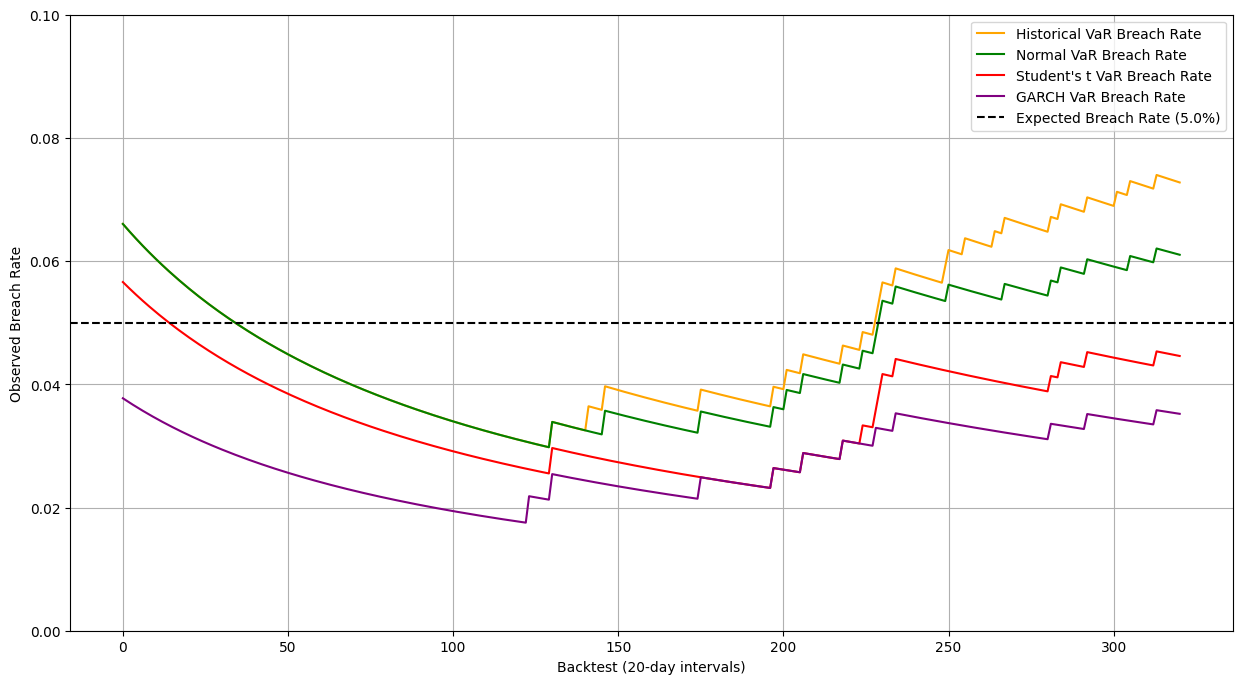

In [88]:

plt.figure(figsize=(15, 8))

plt.plot(BR_H[5:], label='Historical VaR Breach Rate', color='orange')
plt.plot(BR_N[5:], label='Normal VaR Breach Rate', color='green')
plt.plot(BR_T[5:], label="Student's t VaR Breach Rate", color='red')
plt.plot(BR_G[5:], label='GARCH VaR Breach Rate', color='purple')

plt.axhline(y=alpha, color='black',linestyle='--', label=f"Expected Breach Rate ({alpha*100}%)")

plt.ylim(0, 0.1)

plt.xlabel('Backtest (20-day intervals)')
plt.ylabel('Observed Breach Rate')
plt.legend()
plt.grid()
plt.show()

In [90]:
alpha_ht = 0.05
t_obs = len(di["H_breachoVaR"])

print(f"\nPOF Test (alpha_ht={alpha_ht})")

B_H = sum(di["H_breachoVaR"])
p_value_H_pof = POF_test(t_obs, B_H, alpha, alpha_ht)
print(f"Historical VaR POF Test:p-value={p_value_H_pof:.4f}")

B_N = sum(di["N_breachoVaR"])
p_value_N_pof = POF_test(t_obs, B_N, alpha, alpha_ht)
print(f"Normal VaR POF Test:p-value={p_value_N_pof:.4f}")

B_T = sum(di["T_breachoVaR"])
p_value_T_pof = POF_test(t_obs, B_T, alpha, alpha_ht)
print(f"Student's t VaR POF Test:p-value={p_value_T_pof:.4f}")

B_G = sum(di["G_breachoVaR"])
p_value_G_pof = POF_test(t_obs, B_G, alpha, alpha_ht)
print(f"GARCH VaR POF Test:p-value={p_value_G_pof:.4f}")
print(f"\n")
print(f"CIT Test (alpha_ht={alpha_ht})")

p_value_H_cit = CIT(di["H_breachoVaR"], alpha_ht)
print(f"Historical VaR CIT Test: p-value={p_value_H_cit:.4f}")

p_value_N_cit = CIT(di["N_breachoVaR"], alpha_ht)
print(f"Normal VaR CIT Test: p-value={p_value_N_cit:.4f}")

p_value_T_cit = CIT(di["T_breachoVaR"], alpha_ht)
print(f"Student's t VaR CIT Test: p-value={p_value_T_cit:.4f}")

p_value_G_cit = CIT(di["G_breachoVaR"], alpha_ht)
print(f"GARCH VaR CIT Test: p-value={p_value_G_cit:.4f}")


POF Test (alpha_ht=0.05)
refect H0 and accept H1
Historical VaR POF Test:p-value=0.0428
Do not reject H0
Normal VaR POF Test:p-value=0.3118
Do not reject H0
Student's t VaR POF Test:p-value=0.6028
Do not reject H0
GARCH VaR POF Test:p-value=0.1400


CIT Test (alpha_ht=0.05)
Do not reject H0
Historical VaR CIT Test: p-value=0.0824
Do not reject H0
Normal VaR CIT Test: p-value=0.0799
refect H0 and accept H1
Student's t VaR CIT Test: p-value=0.0070
Do not reject H0
GARCH VaR CIT Test: p-value=0.5472
